In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vaukaofworlds/thecycloneimagedataset")
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset


In [2]:
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import os

class CycloneDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        intensity = self.data.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        return image, intensity


In [3]:
# ✅ 1. IMPORTS
import os
import h5py
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import timm
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ✅ 2. LOAD DATA
# Use the 'path' variable returned by kagglehub in the first cell (do NOT hardcode)
image_path = os.path.join(path, "Cyclone_Images.h5")
label_path = os.path.join(path, "Cyclone_Labels h5.npy")

with h5py.File(image_path, 'r') as f:
    images = np.array(f['Images'])

# Extract intensity only (column index 5)
raw_labels = np.load(label_path, allow_pickle=True)
intensity_labels = np.array([float(row[5]) for row in raw_labels], dtype=np.float32)

print("Images shape:", images.shape)
print("Labels shape:", intensity_labels.shape)
print("Sample intensity:", intensity_labels[0])


Images shape: (21076, 128, 128, 4)
Labels shape: (21076,)
Sample intensity: 30.0


In [4]:
class CycloneH5Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]

        # If shape is (C, H, W), convert to (H, W, C)
        if img.shape[0] in [3, 4]:
            img = np.transpose(img, (1, 2, 0))

        # ✅ Force conversion to RGB (drops alpha channel)
        img = np.nan_to_num(img, nan=0.0)                 # Remove NaNs
        img = np.clip(img, 0, 255).astype('uint8')        # Clamp to valid pixel range
        img = Image.fromarray(img).convert('RGB')         # Convert to RGB safely


        label = float(self.labels[idx])

        if self.transform:
            img = self.transform(img)

        return img, label



In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = CycloneH5Dataset(images, intensity_labels, transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("vit_base_patch16_224", pretrained=True)
model.head = nn.Sequential(
    nn.Linear(model.head.in_features, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [7]:
# ✅ TRAINING LOOP (checkpointing + early stopping)
import os, glob

CKPT_DIR = "/kaggle/working"   # writable folder on Kaggle; files here survive the session
os.makedirs(CKPT_DIR, exist_ok=True)

epochs = 10                # target number of epochs
patience = 3               # stop if val loss doesn't improve for this many epochs in a row
best_val = float("inf")    # best validation loss seen so far
epochs_no_improve = 0      # counter for early stopping

# --- Resume from last checkpoint if one exists ---
start_epoch = 0
ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, "checkpoint_epoch_*.pt")),
               key=lambda p: int(p.split("_")[-1].split(".")[0]))
if ckpts:
    last = ckpts[-1]
    print(f"Resuming from {last}")
    state = torch.load(last, map_location=device)
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    start_epoch = state["epoch"]
    best_val = state.get("best_val", float("inf"))
    epochs_no_improve = state.get("epochs_no_improve", 0)
    print(f"Resumed at epoch {start_epoch} | best_val={best_val:.4f}")

for epoch in range(start_epoch, epochs):
    # ---- train ----
    model.train()
    total_loss = 0
    for batch_idx, (imgs, targets) in enumerate(train_loader):
        imgs = imgs.to(device)
        targets = targets.clone().detach().float().to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}")

    avg_loss = total_loss / len(train_loader)

    # ---- validate (used for early stopping) ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.clone().detach().float().to(device).unsqueeze(1)
            outputs = model(imgs)
            val_loss += criterion(outputs, targets).item()
    avg_val = val_loss / len(val_loader)

    print(f"✅ Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val:.4f}")

    # ---- check for improvement ----
    improved = avg_val < best_val
    if improved:
        best_val = avg_val
        epochs_no_improve = 0
        # save the best model separately
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_model.pt"))
        print(f"⭐ New best val loss {best_val:.4f} — saved best_model.pt")
    else:
        epochs_no_improve += 1
        print(f"⏳ No improvement for {epochs_no_improve}/{patience} epoch(s)")

    # ---- save checkpoint (for resume) after EVERY epoch ----
    torch.save({
        "epoch": epoch + 1,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "loss": avg_loss,
        "best_val": best_val,
        "epochs_no_improve": epochs_no_improve,
    }, os.path.join(CKPT_DIR, f"checkpoint_epoch_{epoch+1}.pt"))
    print(f"💾 Saved checkpoint_epoch_{epoch+1}.pt")

    # ---- early stop ----
    if epochs_no_improve >= patience:
        print(f"🛑 Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
        break

print(f"Done. Best val loss: {best_val:.4f}")


Epoch 1, Batch 1/1054
Epoch 1, Batch 11/1054
Epoch 1, Batch 21/1054
Epoch 1, Batch 31/1054
Epoch 1, Batch 41/1054
Epoch 1, Batch 51/1054
Epoch 1, Batch 61/1054
Epoch 1, Batch 71/1054
Epoch 1, Batch 81/1054
Epoch 1, Batch 91/1054
Epoch 1, Batch 101/1054
Epoch 1, Batch 111/1054
Epoch 1, Batch 121/1054
Epoch 1, Batch 131/1054
Epoch 1, Batch 141/1054
Epoch 1, Batch 151/1054
Epoch 1, Batch 161/1054
Epoch 1, Batch 171/1054
Epoch 1, Batch 181/1054
Epoch 1, Batch 191/1054
Epoch 1, Batch 201/1054
Epoch 1, Batch 211/1054
Epoch 1, Batch 221/1054
Epoch 1, Batch 231/1054
Epoch 1, Batch 241/1054
Epoch 1, Batch 251/1054
Epoch 1, Batch 261/1054
Epoch 1, Batch 271/1054
Epoch 1, Batch 281/1054
Epoch 1, Batch 291/1054
Epoch 1, Batch 301/1054
Epoch 1, Batch 311/1054
Epoch 1, Batch 321/1054
Epoch 1, Batch 331/1054
Epoch 1, Batch 341/1054
Epoch 1, Batch 351/1054
Epoch 1, Batch 361/1054
Epoch 1, Batch 371/1054
Epoch 1, Batch 381/1054
Epoch 1, Batch 391/1054
Epoch 1, Batch 401/1054
Epoch 1, Batch 411/1054
Epo

In [8]:
model.eval()
true_labels, predictions = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).cpu().squeeze()
        predictions.extend(outputs.numpy())
        true_labels.extend(targets)

mae = mean_absolute_error(true_labels, predictions)
r2 = r2_score(true_labels, predictions)

print(f"📊 MAE: {mae:.2f}")
print(f"📈 R² Score: {r2:.2f}")


📊 MAE: 5.54
📈 R² Score: 0.93


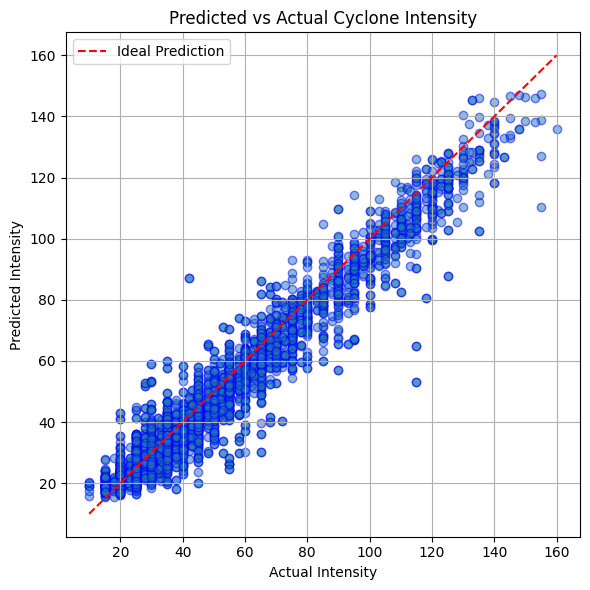

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(true_labels, predictions, alpha=0.5, edgecolors='b')
plt.plot([min(true_labels), max(true_labels)],
         [min(true_labels), max(true_labels)], 'r--', label='Ideal Prediction')
plt.xlabel("Actual Intensity")
plt.ylabel("Predicted Intensity")
plt.title("Predicted vs Actual Cyclone Intensity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=300)
plt.show()


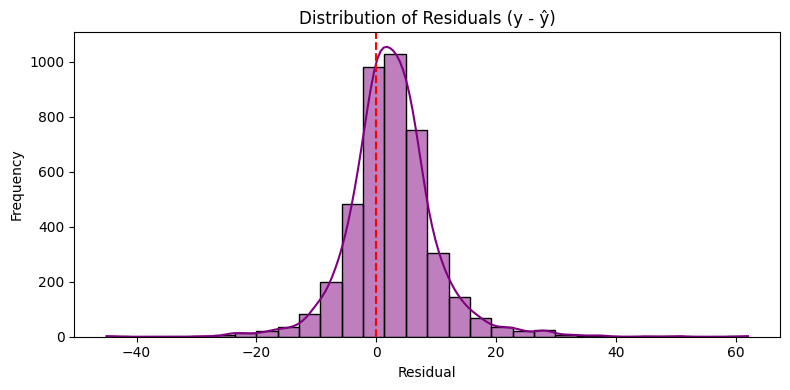

In [10]:
import seaborn as sns

residuals = np.array(true_labels) - np.array(predictions)

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=30, color="purple")
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Residuals (y - ŷ)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300)
plt.show()


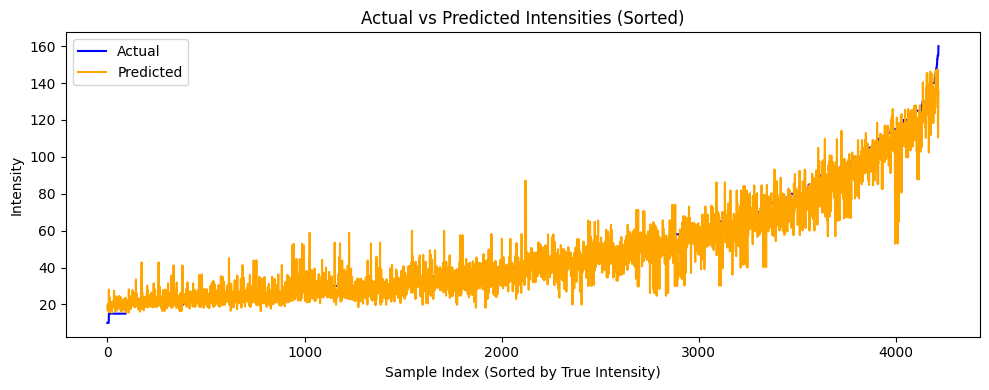

In [11]:
sorted_indices = np.argsort(true_labels)
sorted_true = np.array(true_labels)[sorted_indices]
sorted_pred = np.array(predictions)[sorted_indices]

plt.figure(figsize=(10, 4))
plt.plot(sorted_true, label="Actual", color='blue')
plt.plot(sorted_pred, label="Predicted", color='orange')
plt.title("Actual vs Predicted Intensities (Sorted)")
plt.xlabel("Sample Index (Sorted by True Intensity)")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.savefig("line_plot.png", dpi=300)
plt.show()


/tmp/ipykernel_23/2442732965.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bin = df_plot.groupby('bin')['error'].mean()


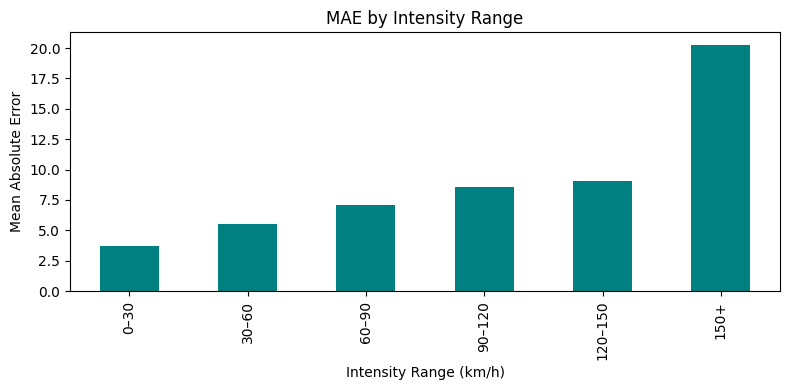

In [12]:
bins = [0, 30, 60, 90, 120, 150, 180]
labels = ['0–30', '30–60', '60–90', '90–120', '120–150', '150+']

df_plot = pd.DataFrame({'true': true_labels, 'pred': predictions})
df_plot['bin'] = pd.cut(df_plot['true'], bins=bins, labels=labels)

df_plot['error'] = abs(df_plot['true'] - df_plot['pred'])
mae_per_bin = df_plot.groupby('bin')['error'].mean()

plt.figure(figsize=(8, 4))
mae_per_bin.plot(kind='bar', color='teal')
plt.title("MAE by Intensity Range")
plt.xlabel("Intensity Range (km/h)")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.savefig("mae_bins.png", dpi=300)
plt.show()

